# Machine Learning Models

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Network-Anomaly-Detection-Project/Dataset/final_data.csv')
data.head()


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,label,total_packets,total_bytes,byte_ratio,packets_per_sec,bytes_per_sec,byte_diff,srv_diff,new_label,attack_cat
0,-0.213727,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.043684,-0.087369,0.057181,0.71944,...,-1.106883,-0.166929,-0.092206,-0.051105,-0.437896,-0.248618,0.031046,-0.172385,0,Normal
1,-0.213728,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.036308,-0.087369,0.286565,0.71944,...,-1.106883,-0.166929,-0.087017,-0.041421,-0.437897,-0.224496,0.036288,-0.172385,0,Normal
2,-0.213729,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.040351,-0.087369,0.791209,0.71944,...,-1.106883,-0.166929,-0.089862,-0.046729,-0.437897,-0.237720,0.033415,-0.171186,0,Normal
3,-0.213729,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.041330,-0.087369,0.566923,0.71944,...,-1.106883,-0.166929,-0.090550,-0.048014,-0.437897,-0.240921,0.032719,-0.171186,0,Normal
4,-0.213728,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.034187,-0.087369,0.118350,0.71944,...,-1.106883,-0.166929,-0.085525,-0.038636,-0.437897,-0.217560,0.037795,-0.171186,0,Normal


In [ ]:
X = data.drop(['label', 'attack_cat','new_label'], axis=1)
y = data['new_label']

#Isolation Forest

In [ ]:
model = IsolationForest(contamination=0.3, random_state=42)

model.fit(X)

IsolationForest(contamination=0.3, random_state=42)

In [ ]:
predictions = model.predict(X)

data['anomaly'] = predictions

In [ ]:
data['anomaly'].value_counts()

,count
anomaly,
1,57632
-1,24700


In [ ]:
anomaly_ratio = len(data[data['anomaly'] == -1]) / len(data)
anomaly_ratio

0.30000485837827334

In [ ]:
pd.crosstab(data['anomaly'], data['attack_cat'])

attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
anomaly,,,,,,,,,,
-1,30,43,710,3896,1139,4880,13843,134,12,13
1,647,540,3379,7236,4923,13991,23157,3362,366,31


In [ ]:
data['predicted'] = data['anomaly'].apply(lambda x: 0 if x == 1 else 1)

y_true = y
y_pred = data['predicted']

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.63      0.49     37000
           1       0.44      0.24      0.31     45332

    accuracy                           0.41     82332
   macro avg       0.42      0.43      0.40     82332
weighted avg       0.42      0.41      0.39     82332



#Random Forest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
      )


rf_model = RandomForestClassifier(
    n_estimators=100,
        random_state=42
        )

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      7400
           1       0.99      0.97      0.98      9067

    accuracy                           0.98     16467
   macro avg       0.98      0.98      0.98     16467
weighted avg       0.98      0.98      0.98     16467



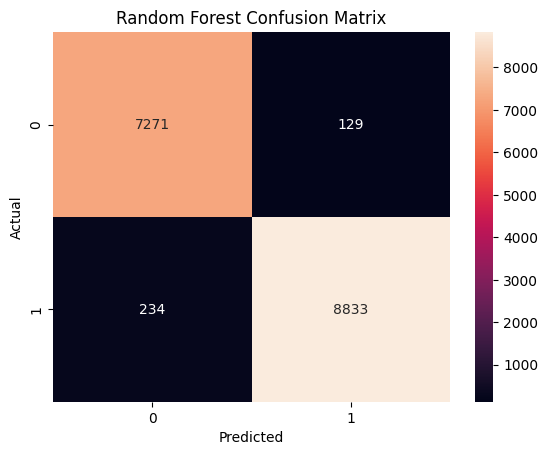

In [ ]:
cm = confusion_matrix(y_test,y_pred_rf)

sns.heatmap(cm,annot=True,fmt='d')


plt.title('Random Forest Confusion Matrix')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# XGBOOST


In [ ]:
xgb_model = XGBClassifier(
      n_estimators=200,
      max_depth=8,
      learning_rate=0.05,
      random_state=42,
      use_label_encoder=False,
      eval_metric='logloss'
                          )

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:39:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7400
           1       0.99      0.97      0.98      9067

    accuracy                           0.98     16467
   macro avg       0.98      0.98      0.98     16467
weighted avg       0.98      0.98      0.98     16467



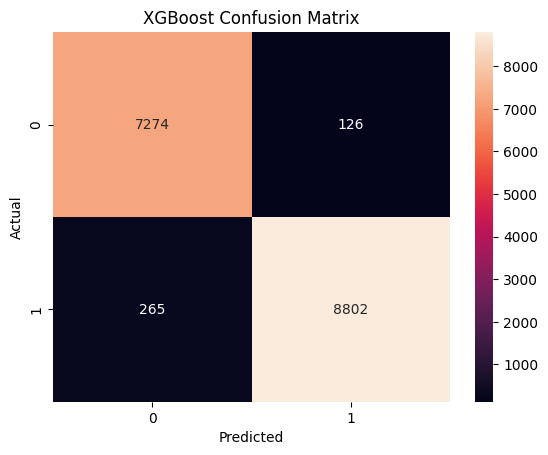

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Multi-class XGBoost

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(data['attack_cat'])

y_mc = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
      X, y_mc, test_size=0.2, random_state=42, stratify=y
      )


In [ ]:
xgb_mc_model = XGBClassifier(
     n_estimators=200,
     max_depth=8,
     learning_rate=0.05,
     objective='multi:softmax',
     num_class=len(set(y_mc)),
     random_state=42
                     )

xgb_mc_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=10, ...)

In [ ]:
y_pred_mc = xgb_mc_model.predict(X_test)

print(classification_report(y_test, y_pred_mc))


              precision    recall  f1-score   support

           0       1.00      0.08      0.15       134
           1       0.36      0.03      0.06       125
           2       0.48      0.57      0.52       816
           3       0.73      0.71      0.72      2236
           4       0.69      0.71      0.70      1279
           5       0.99      0.98      0.99      3723
           6       0.96      0.99      0.97      7400
           7       0.92      0.82      0.87       669
           8       0.60      0.56      0.58        80
           9       0.60      0.60      0.60         5

    accuracy                           0.88     16467
   macro avg       0.73      0.60      0.62     16467
weighted avg       0.88      0.88      0.88     16467



In [ ]:
le.classes_

array(['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic',
       'Normal', 'Reconnaissance', 'Shellcode', 'Worms'], dtype=object)

#  VISUALIZATION

Models Comparison

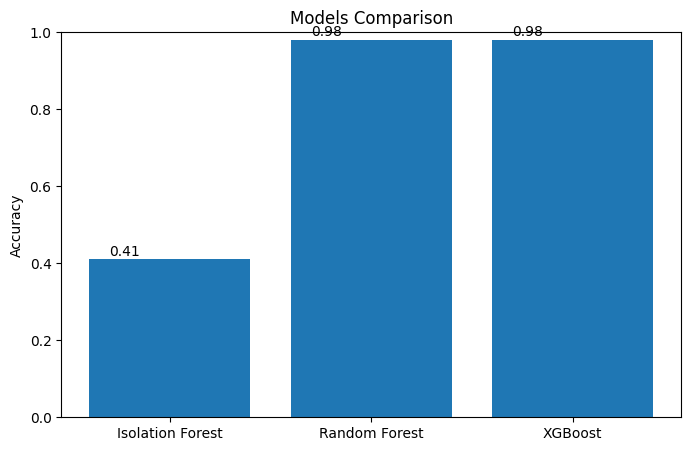

In [34]:
models = ['Isolation Forest', 'Random Forest', 'XGBoost']
accuracy = [0.41, 0.98, 0.98]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracy)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Models Comparison")
plt.savefig("model_comparison.png", bbox_inches='tight')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.1, yval + 0.01, round(yval,2))


Recall Comparison for Attacks


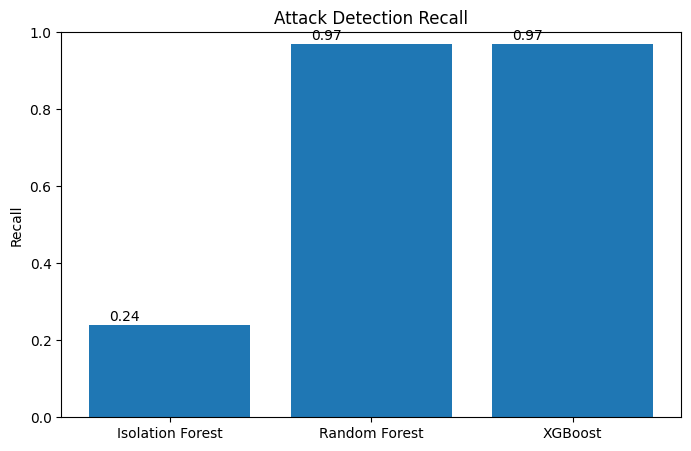

In [ ]:
models = ['Isolation Forest', 'Random Forest', 'XGBoost']
recall_attack = [0.24, 0.97, 0.97]

plt.figure(figsize=(8,5))

bars = plt.bar(models, recall_attack)

plt.ylim(0,1)
plt.ylabel("Recall")
plt.title("Attack Detection Recall")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.1, yval + 0.01, round(yval,2))

plt.show()

Attack Category Distribution

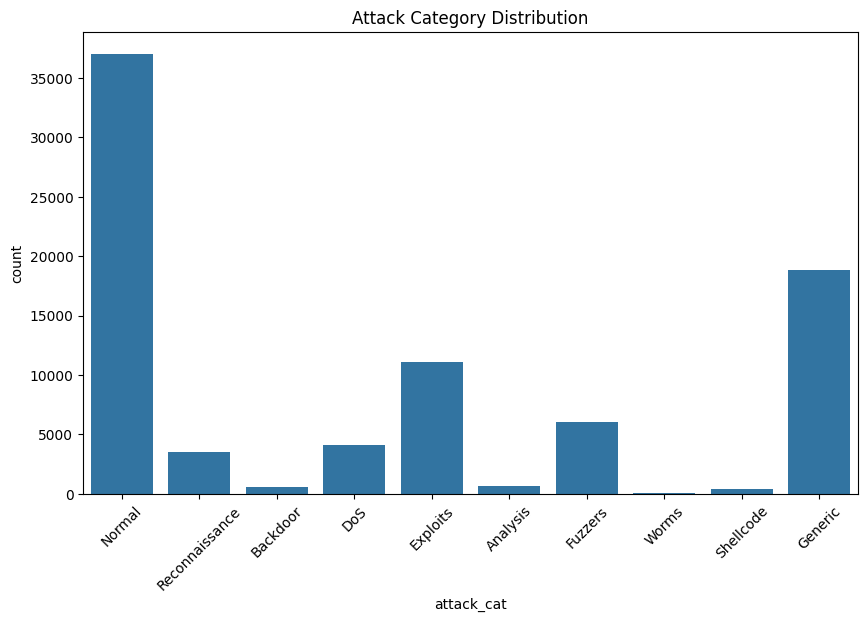

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x='attack_cat', data=data)

plt.xticks(rotation=45)
plt.title("Attack Category Distribution")

plt.show()

Features Importance

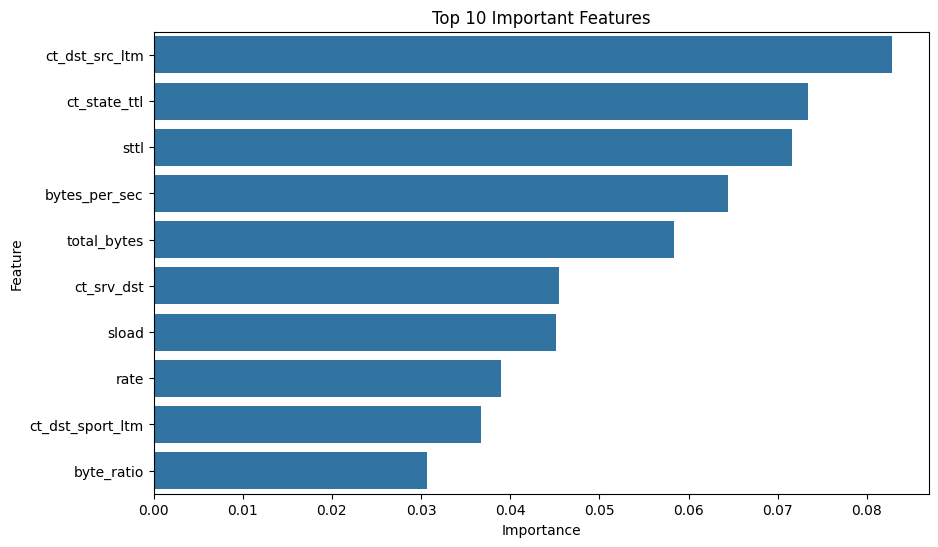

In [35]:
importance = rf_model.feature_importances_

feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
                    })

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
        x='Importance',
        y='Feature',
        data=feat_imp.head(10)
              )
plt.title("Top 10 Important Features")
plt.savefig("Important Features.png", bbox_inches='tight')
plt.show()

Multi-class Confusion Matrix

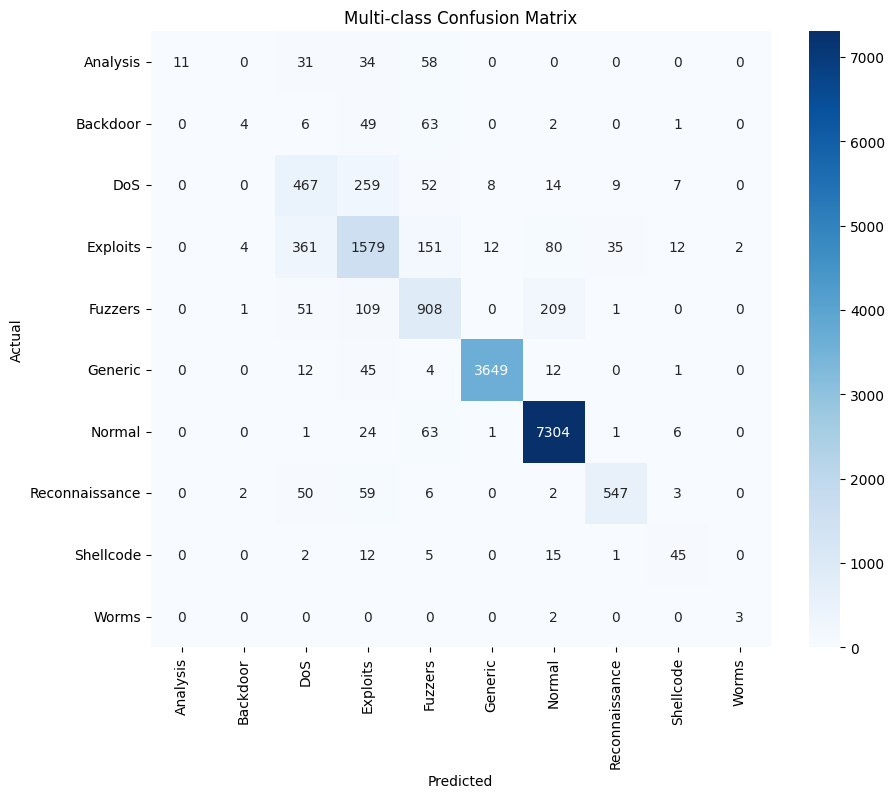

In [ ]:
cm = confusion_matrix(y_test, y_pred_mc)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_      )

plt.title("Multi-class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()